# SPARC PRD: fusdb vs cfspopcon full-grid comparison

This notebook is the human-readable companion to `test_sparc_prd.py`. It runs
fusdb's `Reactor.popcon` scan over the **same 40×30 `(n_e, T_e)` grid** cfspopcon
scanned in `input.yaml`, then compares every field against cfspopcon's reference
`output/dataset.nc` cell-by-cell over the certified operating region.

The fixture (`reactor.yaml`) is driven from input.yaml's inputs — geometry,
field, current, and the impurity concentrations (He 6e-2, O 3.1e-3, W 1.5e-5
of `n_e`), which drive the line radiation, the **derived** `Z_eff` (~1.34,
within ~1% of the reference, via the Mavrin 2018 T-dependent mean charges) and
the scalar ion-inventory anchor `n_i_avg` (the f-fractions keep the species
split: helium as `f_He4`, O+W folded into the generic Z=6 impurity by
quasineutrality charge). Profiles carry **both** Angioni density-peaking
offsets (electron −0.1 and ion −0.2), plus the Martin+Ryter L-H scaling and
cfspopcon's stored-energy and ITER98y2 conventions. The CS flux consumption
uses input.yaml's `ejima_coefficient` (0.6) and `total_flux_available_from_CS`,
plus cfspopcon's `kappa_95` (= areal/1.025), which makes the internal
inductance and hence the flat-top duration match.

**fusdb still works as fusdb.** Nothing about the solver was bent to match: the
match comes from *selecting* the relations that encode cfspopcon's modelling
choices (`Poloidal beta (cfspopcon)`, `Average total pressure (cfspopcon)`,
`Normalized beta (cfspopcon)`, `Plasma stored energy (cfspopcon)`, `Energy
confinement time ITER98y2 (cfspopcon)`, `L-H transition threshold power
(Martin-Ryter)`, `Hydrogenic bremsstrahlung (cfspopcon)`, `Impurity line
radiation (radas coronal)`, `Elongation at psi95 from areal elongation
(cfspopcon)`) instead of fusdb's more general defaults, and supplying the same
composition. Radiation follows cfspopcon's convention
`P_rad = P_brem(Z_eff=1) + P_sync + P_line`: the impurity cooling curves
already include each impurity's own continuum, so the Z_eff-scaled
bremsstrahlung would double-count it. `P_line` runs on the radas (OpenADAS)
coronal Lz tables — the reference's own radiation method (the Mavrin-2018
polynomial fits stay the fusdb default elsewhere). The **beta/pressure chain**
matches too: `Average total pressure (cfspopcon)` makes `p_th` the undiluted
product of averages `n_e(T_e+T_i)` that cfspopcon's beta diagnostics are built
on (fusdb's profile-integrated pressure stays the default elsewhere; the
*energy* balance separately uses cfspopcon's `W`), which closes `beta_T`,
`beta`, `beta_p`, `beta_N` and — through `beta_p` — the bootstrap fraction.
The pointwise `n_i ∝ n_e` profile tie is a *weak default* in fusdb: here the
ion profile decouples through its own Angioni peaking and parabolic generator,
with quasineutrality anchored at the averages level — the same structure
cfspopcon has, where the fuel peaks less than the electrons and the impurity
fraction varies radially.

The table below reports the **median relative error** over the certified cells for
every mappable field, grouped by category, **including the fields fusdb does not
compute on the scan** (`missing`) so the gaps stay explicit. See the `FIELDS`
table and `reactor.yaml` comments for the physics behind each category.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# _compare.py lives next to this notebook.
sys.path.insert(0, str(Path.cwd()))
import _compare as C

result = C.run_scan(outputs=C.SCAN_OUTPUTS)
handle = C.load_dataset()
comparisons = C.compare(result, handle)

success = result["popcon"]["success"]
print(f"certified {int(success.sum())} / {success.size} grid points")

Included relation 'L-H transition threshold power (Martin-Ryter)' is not a preferred provider of 'P_LH'; it overrides the default_relation set declared in variables.yaml (P_LH: ['L-H transition threshold power']). This is allowed, but the preferred provider(s) remain active alongside it unless excluded.
Included relation 'Poloidal beta (cfspopcon)' is not a preferred provider of 'beta_p'; it overrides the default_relation set declared in variables.yaml (beta_p: ['Poloidal beta']). This is allowed, but the preferred provider(s) remain active alongside it unless excluded.
Included relation 'Average total pressure (cfspopcon)' is not a preferred provider of 'p_th'; it overrides the default_relation set declared in variables.yaml (p_th: ['Thermal pressure']). This is allowed, but the preferred provider(s) remain active alongside it unless excluded.
Included relation 'Normalized beta (cfspopcon)' is not a preferred provider of 'beta_N'; it overrides the default_relation set declared in vari

certified 768 / 1200 grid points


## Field-by-field agreement

`match` — fusdb reproduces cfspopcon within ~10% grid-wide (asserted by the test).
`fusion` — fusion chain, ~6% median (fuel profile on its own ion peaking).
`gap` — a known modelling difference (carried as `xfail`).
`missing` — fusdb does not compute this on the scan (shown so it can be closed).

With the decoupled ion profile the scan is essentially exact where the physics
is shared: `P_in` ~0.0%, `tau_E` ~0.0%, both density peakings ~0.4%, `P_aux`
~2%, `P_fus` ~6% (PRD cell +0.8%). The radiation chain is closed: with the
radas 2-D `Lz(T_e, n_e)` tables evaluated pointwise on the real He/O/W mix (the
reference's own method, same bicubic log-log spline), **`P_radiation` dropped
from ~53% (no line radiation) through ~14% (Mavrin fits) to ~3% median** — now
a `match` — which pulled `P_sep` to ~0.3% and `P_SOL/P_LH` to ~8.5%. The
**beta/pressure chain also matches now** (~0%): selecting cfspopcon's
product-of-averages `p_th` closes `beta_T`/`beta`/`beta_p`/`beta_N` and makes
the bootstrap fraction exact. The **CS flux and flat-top duration match** too
(`flux_needed` ~0%, `t_flattop` ~0.4%): input.yaml's `ejima_coefficient` and
cfspopcon's `kappa_95` make the resistive and internal-inductance fluxes exact.
On the **low-density side** `flux_needed > 35` Wb → a **negative** flat-top
(there `beta_p` is small, so the subtracted `poloidal_field_flux` gives little
assistance and the CS cannot even cover rampup); that is a genuinely infeasible
operating point, so fusdb does not certify it — the certified region is the
~768 feasible cells, every one of which lands where cfspopcon also reports a
feasible flat-top (cfspopcon instead reports the negative value).

One honest consequence: correcting `beta_p` made `f_BS` exact but **removed an
error cancellation that had been flattering `Q`** — the old `Q` ~9% match was
partly the wrong `f_BS` compensating in the `P_aux` balance. With correct
physics `Q` sits at ~10.2% (well-conditioned ~9.6%; the near-ignition cells
where `P_aux → 0` drag the median over 10%), so `Q` is now the one documented
`gap` rather than masking those cells. The He3 side-channels (D-He3, T-He3,
He3-He3) are pruned — with no He3 in the plasma their rate variables would
otherwise be unconstrained free cores producing spurious fusion power.

In [2]:
_cat_order = {"match": 0, "fusion": 1, "gap": 2, "missing": 3}
rows = []
for c in comparisons:
    rows.append({
        "category": c.category,
        "cfspopcon field": c.dataset_name,
        "fusdb variable": c.fusdb_name,
        "cells": c.n_cells,
        "median %": np.nan if not c.computed else round(c.median_rel * 100, 1),
        "max %": np.nan if not c.computed else round(c.max_rel * 100, 1),
        "within 10%": np.nan if not c.computed else round(c.frac_within_10 * 100, 0),
    })
df = pd.DataFrame(rows)
df = df.sort_values(
    by=["category", "median %"],
    key=lambda s: s.map(_cat_order) if s.name == "category" else s,
    na_position="last",
).reset_index(drop=True)


def _highlight(row):
    color = {"match": "#e6ffe6", "fusion": "#fffbe6", "gap": "#ffefe6", "missing": "#f0f0f0"}[row["category"]]
    return [f"background-color: {color}"] * len(row)


df.style.apply(_highlight, axis=1).format({"median %": "{:.1f}", "max %": "{:.1f}", "within 10%": "{:.0f}"}, na_rep="—")

,category,cfspopcon field,fusdb variable,cells,median %,max %,within 10%
0,match,average_ion_temp,T_i_avg,768,0.0,0.0,100
1,match,dilution,dilution,768,0.0,0.0,100
2,match,greenwald_fraction,f_GW,768,0.0,0.0,100
3,match,peak_electron_temp,T0,768,0.0,0.0,100
4,match,peak_ion_temp,T_i_peak,768,0.0,0.0,100
5,match,P_in,P_in,768,0.0,0.2,100
6,match,energy_confinement_time,tau_E,768,0.0,0.1,100
7,match,plasma_stored_energy,W_th,768,0.0,0.0,100
8,match,average_total_pressure,p_th,768,0.0,0.0,100
9,match,beta_toroidal,beta_T,768,0.0,0.0,100


### Summary by category

In [3]:
computed = df[df["cells"] > 0]
summary = computed.groupby("category").agg(
    n_fields=("cfspopcon field", "count"),
    median_of_medians=("median %", "median"),
)
n_missing = int((df["cells"] == 0).sum())
print(summary)
print(f"\nfields fusdb does not compute on the scan (missing): {n_missing}")

          n_fields  median_of_medians
category                             
fusion           4               6.35
gap              1              10.10
match           57               0.00

fields fusdb does not compute on the scan (missing): 2


## Operating-space contour overlay

`P_fus`, `Q`, `P_aux`, `P_SOL/P_LH` and `t_flattop` on the `(n_e, T_e)` plane:
**fusdb solid, cfspopcon dashed**, one colour per quantity.

Reading the overlay:

* **Grey shaded region — fusdb does not certify it.** Run in `h_mode` across the
  whole grid (faithful to cfspopcon's single ITER98y2 scaling), fusdb certifies
  `T_e ≳ 9` keV: below that the H-mode power/confinement balance needs negative
  auxiliary power, so those cells fail. cfspopcon reports them anyway, so its
  dashed contours continue into the shading while the fusdb solid lines stop at
  its edge — that boundary (not a bug) is why the solid lines look 'interrupted'
  around `T_e ≈ 9`. The **low-density side** is also shaded: there the CS
  flat-top goes negative, which fusdb treats as infeasible (next bullet).

* **`Q` is compared as `Q_cfspopcon`** — cfspopcon's own definition, `Q =
  P_fus / (P_aux_launched + P_ohmic)` (its dataset `P_external` equals
  `P_aux_launched + P_ohmic` exactly). fusdb's `Q_sci = P_fus / P_aux` drops the
  ohmic term, so it diverges to infinity where `P_aux → 0` while cfspopcon's Q
  stays finite — comparing on one definition removes that artificial blow-up.
  On this definition `Q` is a documented `gap` at ~10.2% median (well-conditioned
  ~9.6%): near ignition `P_aux → 0` makes `Q` hypersensitive, and the correct
  `f_BS` from the beta/pressure import removed a cancellation that had flattered
  it to ~9%.

* **`t_flattop` contours overlap** (fusdb solid on cfspopcon dashed, ~0.4%):
  selecting cfspopcon's `kappa_95` makes the internal inductance and hence
  `flux_needed` exact, so `t_flattop = (total_flux − flux_needed)/loop_voltage`
  matches. The **`0` s contour is the CS feasibility boundary** (`flux_needed =
  total_flux_available_from_CS`). Note `t_flattop = 0` is itself a **valid**
  value — the domain is `[0, ∞)`, closed at 0, so the marginal zero-flat-top
  point certifies; only a *strictly negative* flat-top is infeasible. Below the
  line — the low-density side, where `beta_p` is small so the subtracted
  `poloidal_field_flux` gives little assistance — the CS cannot even cover
  rampup, and fusdb does not certify those cells (cfspopcon instead reports the
  negative value, −9.6..+74 s). Only cfspopcon's dashed `0` line renders, simply
  because its data brackets zero; fusdb's contours approach the same line from
  the valid side (its lowest certified flat-top is ~0.002 s). Every cell fusdb
  *does* certify lies inside cfspopcon's feasible region.

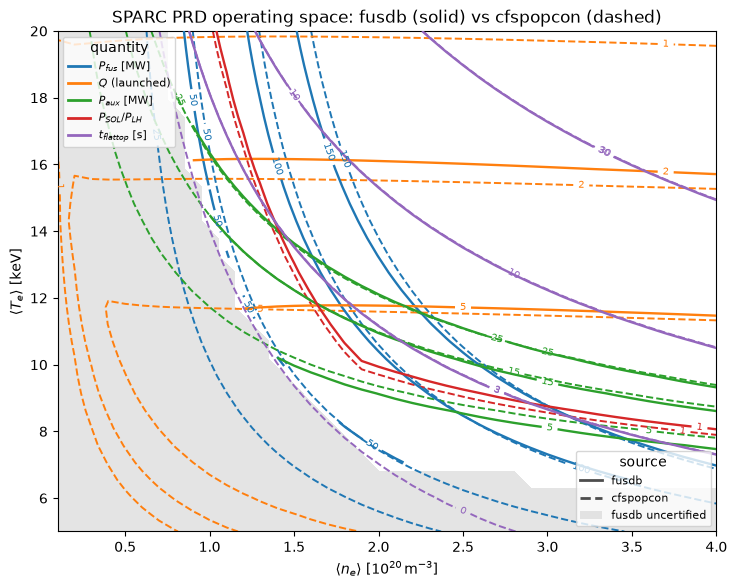

In [4]:
import matplotlib.pyplot as plt

ax = C.contour_overlay(result, handle)
plt.show()

## Native automatic per-point regime

`Reactor.popcon` now selects the confinement regime **per grid point
automatically** — there is no fixed-regime option. For each cell it runs the
machine's escalation chain (`h_mode`/`l_mode`/`ohmic_mode`, or
`i_mode`/`l_mode`/`ohmic_mode`) and assigns the strongest regime whose
sustainment guard holds on that regime's own solve: H-mode where
`P_sep >= P_LH`, ohmic where `P_sep <= P_OL_thresh`, with L-mode as the
accessible fallback for the intermediate / L-H-bistable band. The result
carries a `regime_index` map (the background colour below), and the whole
operating space is covered. `run_scan_multiregime` is now just
`reactor.popcon(...)`.

**Caveat (unchanged):** L-mode cells use the L-mode `tau_E` scaling, not
cfspopcon's H-mode ITER98y2, so their values diverge from `dataset.nc` there by
construction — the fusdb solid contours **kink at the H/L boundary**. The
faithful value comparison (the table above) is therefore taken against a
forced-`h_mode` scan, matching cfspopcon's single-scaling choice.

Included relation 'L-H transition threshold power (Martin-Ryter)' is not a preferred provider of 'P_LH'; it overrides the default_relation set declared in variables.yaml (P_LH: ['L-H transition threshold power']). This is allowed, but the preferred provider(s) remain active alongside it unless excluded.
Included relation 'Poloidal beta (cfspopcon)' is not a preferred provider of 'beta_p'; it overrides the default_relation set declared in variables.yaml (beta_p: ['Poloidal beta']). This is allowed, but the preferred provider(s) remain active alongside it unless excluded.
Included relation 'Average total pressure (cfspopcon)' is not a preferred provider of 'p_th'; it overrides the default_relation set declared in variables.yaml (p_th: ['Thermal pressure']). This is allowed, but the preferred provider(s) remain active alongside it unless excluded.
Included relation 'Normalized beta (cfspopcon)' is not a preferred provider of 'beta_N'; it overrides the default_relation set declared in vari

Included relation 'PRF ion temperature profile' is not a preferred provider of 'T_i'; it overrides the default_relation set declared in variables.yaml (T_i: ['Default ion temperature profile from average temperature', 'Parabolic ion temperature profile']). This is allowed, but the preferred provider(s) remain active alongside it unless excluded.
Included relation 'Hydrogenic bremsstrahlung (cfspopcon)' is not a preferred provider of 'P_brem'; it overrides the default_relation set declared in variables.yaml (P_brem: ['Bremsstrahlung radiation']). This is allowed, but the preferred provider(s) remain active alongside it unless excluded.
Included relation 'Line radiation equals impurity cooling rate (cfspopcon convention)' is not a preferred provider of 'P_line'; it overrides the default_relation set declared in variables.yaml (P_line: ['Line radiation from impurity cooling rate']). This is allowed, but the preferred provider(s) remain active alongside it unless excluded.
Included relatio

h_mode     : 579 cells
l_mode     : 240 cells
ohmic_mode : 0 cells
no regime  : 381 cells   (certified 819/1200)


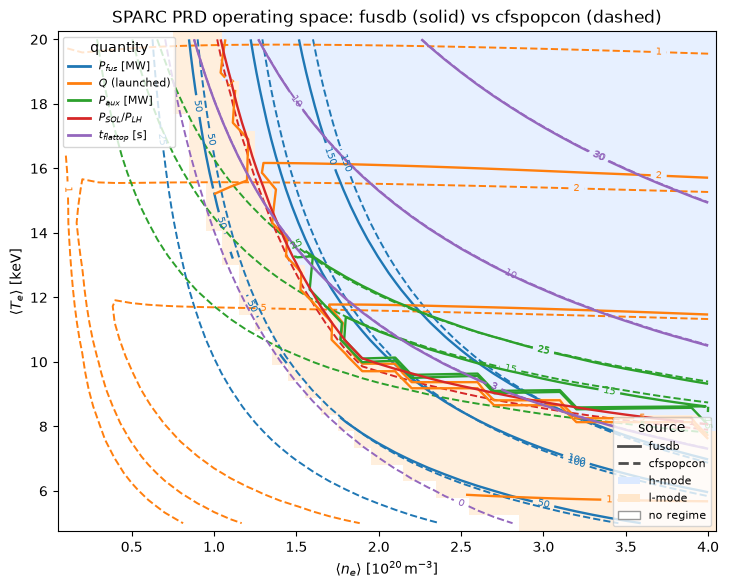

In [5]:
multi = C.run_scan_multiregime(outputs=C.SCAN_OUTPUTS)
ri = multi["popcon"]["regime_index"]
for i, name in enumerate(multi["popcon"]["regime_names"]):
    print(f"{name:11s}: {int((ri == i).sum())} cells")
print(f"no regime  : {int((ri < 0).sum())} cells   (certified {int(multi['popcon']['success'].sum())}/1200)")

ax = C.contour_overlay(multi, handle)
plt.show()

In [6]:
handle.close()